<a href="https://colab.research.google.com/github/yangyi02/droid/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DROID Multi-View 3D Tracking Pipeline

This notebook is a **thin orchestration layer** — all algorithm code lives in the GitHub repo.

**Four stages** controlled by global flags (Stages 1–3 can compute or load from GCS):

| Stage | Compute | Load from GCS | Output |
|---|---|---|---|
| 1. Depth | `compute_depth.py` | `gs://dm-tapnet/tmp/droid/depth/` | Stereo depth + gripper refinement |
| 2. Extrinsics | `compute_extrinsics.py` | `gs://dm-tapnet/tmp/droid/extrinsics/` | Camera-robot alignment |
| 3. Tracks | `compute_tracks.py` | `gs://dm-tapnet/tmp/droid/tracks/` | Static BG + Robot 3D tracks |
| 4. Metrics | `compute_metrics.py` | — | Quality metrics + visualization |

---
## 0. Environment Setup

In [1]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
  subprocess.run(
    ["git", "clone", "--recursive", "https://github.com/yangyi02/droid.git", "/content/droid"],
    check=True,
  )
  os.chdir("/content/droid")

REPO_DIR = os.getcwd()
CACHE_DIR = os.path.join(REPO_DIR, "data", "cache")
GCS_OUTPUT = "gs://dm-tapnet/tmp/droid"
print(f"cache: {CACHE_DIR}")

cache: /home/yiya_google_com/droid/data/cache


In [2]:
COMPUTE_DEPTH = False
COMPUTE_EXTRINSICS = False
COMPUTE_TRACKS = True

print(f"COMPUTE_DEPTH      = {COMPUTE_DEPTH}")
print(f"COMPUTE_EXTRINSICS = {COMPUTE_EXTRINSICS}")
print(f"COMPUTE_TRACKS     = {COMPUTE_TRACKS}")

COMPUTE_DEPTH      = False
COMPUTE_EXTRINSICS = False
COMPUTE_TRACKS     = True


In [3]:
if IN_COLAB:
  from google.colab import auth

  auth.authenticate_user()

  subprocess.run([sys.executable, "-m", "pip", "install", "-U", "ipython"], check=True)

  subprocess.run(["bash", "setup.sh"] + ([] if COMPUTE_DEPTH else ["--no-depth"]), check=True)
else:
  print("[SKIP] local checkout — dependencies come from setup.sh / the venv")

[SKIP] local checkout — dependencies come from setup.sh / the venv


In [4]:
import random

import matplotlib.pyplot as plt
import mediapy as media
import numpy as np
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda:0


In [5]:
%reload_ext autoreload
%autoreload 2

from config import get_config
import core.depth
import core.geometry
import core.io
import core.physics
import core.visualization
import compute_depth
import compute_extrinsics
import compute_metrics
import compute_tracks

config = get_config()

pybullet build time: Sep  2 2026 03:26:18


In [6]:
serials_db, id_to_path, extrinsics_db, _ = core.io.load_metadata(config)

with open(os.path.join(REPO_DIR, "episodes_success.txt")) as f:
  valid_ids = sorted(line.strip() for line in f if line.strip())
print(f"{len(valid_ids)} successful episodes to pick from")

3403 successful episodes to pick from


In [7]:
episode_id = random.choice(valid_ids)

print(f"Episode: {episode_id}")

Episode: IPRL+edf28ef3+2023-12-18-18h-47m-27s


In [8]:
episode = compute_depth.init_episode(episode_id, config.paths.raw, id_to_path, serials_db)

print(f"episode loaded: {list(episode['camera'].keys())}")

episode loaded: ['12391924', '27432424', '28221883']


---
## 1. Stage 1: Depth

Stereo depth via S2M2 + SAM gripper refinement.

In [9]:
if COMPUTE_DEPTH:
  s2m2_model, sam_predictor, run_stereo_matching = compute_depth.init_all_models()

  episode = compute_depth.extract_svo_video(episode, config.depth.min_frames, config.depth.max_frames)
  episode = compute_depth.parse_robot_kinematics(episode)
  episode = compute_depth.align_temporal_streams(episode)
  episode = core.depth.compute_stereo_depth(episode, s2m2_model, run_stereo_matching, device, config.depth.conf_thresh)

  wrist_data = episode["camera"][episode["meta"]["wrist_serial"]]
  wrist_data["original_raw_depth"] = wrist_data["raw_depth"].copy()
  episode = core.depth.build_universal_gripper_mask(
    episode,
    sam_predictor,
    config.depth.consensus_thresh,
    config.depth.gripper_closed_thresh,
    config.depth.mask_area_min,
    config.depth.mask_area_max,
  )
  episode = core.depth.distill_empirical_gripper_depth(
    episode, config.depth.max_depth_thresh, config.depth.gripper_closed_thresh
  )
  episode = core.depth.inject_gripper_depth(episode, config.depth.gripper_closed_thresh)

  print("Stage 1 (Depth) COMPUTE complete")
else:
  depth_root = os.path.join(CACHE_DIR, "depth")
  src = f"{GCS_OUTPUT}/depth/{episode_id}"
  dst = os.path.join(depth_root, episode_id)
  subprocess.run(["gcloud", "storage", "rsync", "-r", src, dst], check=True)

  episode = core.io.load_depth_data(episode_id, depth_root, load_video=True)

  print("Stage 1 LOADED from GCS")

At gs://dm-tapnet/tmp/droid/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/**, worker process 617691 thread 135637985675072 listed 22...
Copying gs://dm-tapnet/tmp/droid/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/calibration.npz to file:///home/yiya_google_com/droid/data/cache/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/calibration.npz
Copying gs://dm-tapnet/tmp/droid/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/gripper_depth.npz to file:///home/yiya_google_com/droid/data/cache/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/gripper_depth.npz
  
Copying gs://dm-tapnet/tmp/droid/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/gripper_mask.npz to file:///home/yiya_google_com/droid/data/cache/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/gripper_mask.npz
Copying gs://dm-tapnet/tmp/droid/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/original_raw_depth.npz to file:///home/yiya_google_com/droid/data/cache/depth/IPRL+edf28ef3+2023-12-18-18h-47m-27s/1239

Stage 1 LOADED from GCS


In [10]:
core.visualization.inspect_dict_structure(episode)

frames = core.visualization.render_multicam_disparity_video(episode, max_frames=30)
media.show_video(frames, fps=10, title="Depth [left | right | disparity] per camera")

episode (dict, 3 keys)
  meta (dict, 2 keys)
    episode_id: str = IPRL+edf28ef3+2023-12-18-18h-47m-27s
    wrist_serial: str = 12391924
  robot (dict, 4 keys)
    joint_positions: ndarray, shape=(130, 7), dtype=float32
    gripper_positions: ndarray, shape=(130,), dtype=float32
    T_ee_base_all: ndarray, shape=(130, 4, 4), dtype=float32
    T_cam_ee_init: ndarray, shape=(4, 4), dtype=float32
  camera (dict, 3 keys)
    12391924 (dict, 8 keys)
      K: ndarray, shape=(3, 3), dtype=float32
      baseline: float = 0.06300000101327896
      raw_depth: ndarray, shape=(130, 720, 1280), dtype=float32
      video_rgb: _VideoArray, shape=(130, 720, 1280, 3), dtype=uint8
      video_right: _VideoArray, shape=(130, 720, 1280, 3), dtype=uint8
      sam_real_masks: ndarray, shape=(130, 720, 1280), dtype=bool
      original_raw_depth: ndarray, shape=(130, 720, 1280), dtype=float32
      empirical_gripper_depth: ndarray, shape=(720, 1280), dtype=float32
    27432424 (dict, 5 keys)
      K: ndarray,

Depth [left | right | disparity] per camera This browser does not support the video tag.


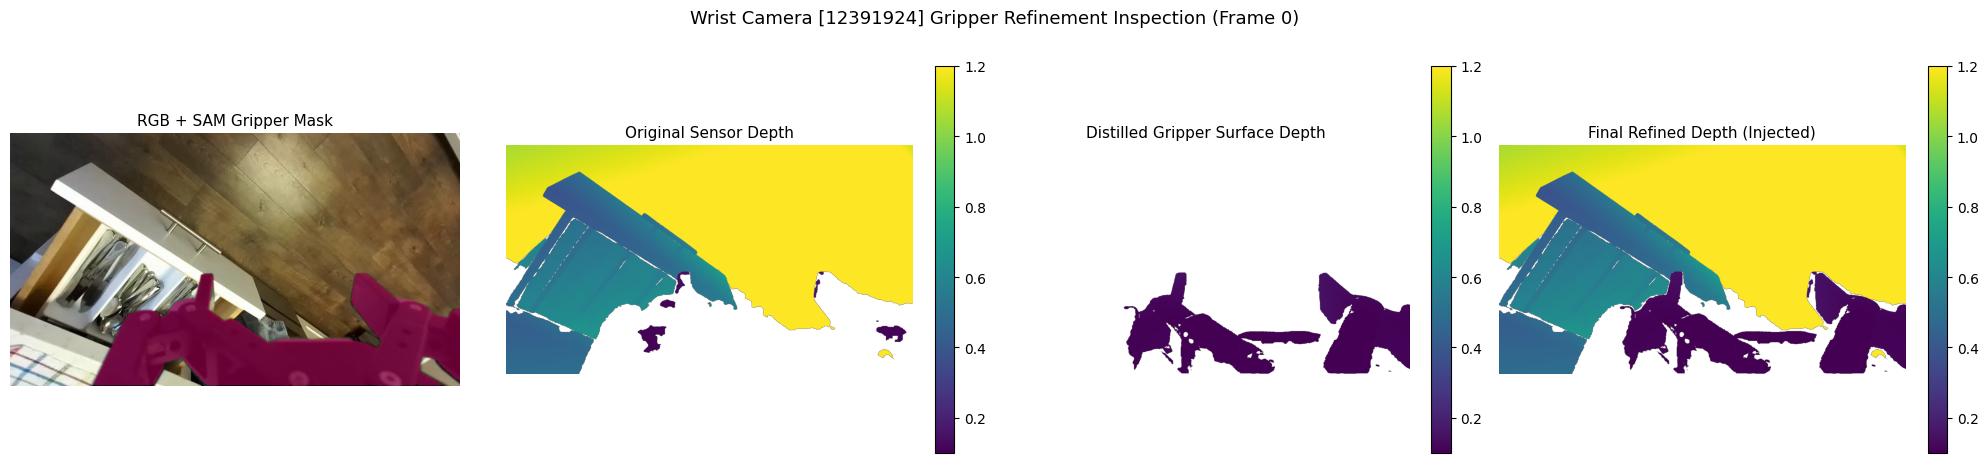

In [11]:
core.visualization.show_gripper_refinement(episode, t=0)

cam_data = episode["camera"][episode["meta"]["wrist_serial"]]
core.visualization.show_distilled_gripper_3d(
  median_depth=cam_data["empirical_gripper_depth"],
  K=cam_data["K"],
  img_rgb=cam_data["video_rgb"][0],
)

---
## 2. Stage 2: Extrinsics

Dataset extrinsics → differentiable robot alignment → global joint optimization.

In [12]:
pb_renderer = core.physics.PyBulletRenderer(config.paths.urdf, gpu=config.render.gpu)
print(f"PyBulletRenderer EGL: {pb_renderer.gpu}")

if COMPUTE_EXTRINSICS:
  poses = compute_extrinsics.init_camera_states(episode, extrinsics_db)

  poses = compute_extrinsics.per_camera_alignment(episode, pb_renderer, poses, device, config)

  poses = compute_extrinsics.global_joint_alignment(episode, poses, pb_renderer, device, config)

  print("Stage 2 (Extrinsics) COMPUTE complete")
else:
  ext_root = os.path.join(CACHE_DIR, "extrinsics")
  src = f"{GCS_OUTPUT}/extrinsics/{episode_id}"
  dst = os.path.join(ext_root, episode_id)
  subprocess.run(["gcloud", "storage", "rsync", "-r", src, dst], check=True)

  poses = core.io.load_extrinsics(episode, ext_root)

  print("Stage 2 LOADED from GCS")

Loaded EGL 1.5 after reload.
GL_VENDOR=NVIDIA Corporation
GL_RENDERER=NVIDIA A100-SXM4-40GB/PCIe/SSE2
GL_VERSION=3.3.0 NVIDIA 580.173.02
GL_SHADING_LANGUAGE_VERSION=3.30 NVIDIA via Cg compiler
Version = 3.3.0 NVIDIA 580.173.02
Vendor = NVIDIA Corporation
Renderer = NVIDIA A100-SXM4-40GB/PCIe/SSE2


EGL device choice: -1 of 32.


b3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
No inertial data for link, using mass=1, localinertiadiagonal = 1,1,1, identity local inertial frameb3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
panda_link0PyBulletRenderer EGL: True
b3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
No inertial data for link, using mass=1, localinertiadiagonal = 1,1,1, identity local inertial frameb3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
panda_link0_scb3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
No inertial data for link, using mass=1, localinertiadiagonal = 1,1,1, identity local inertial frameb3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
panda_link1b3Warning[examples/Importers/ImportURDFDemo/BulletUrdfImporter.cpp,126]:
No inertial data for link, using mass=1, localinertiadiagonal = 1,1,1, identity local inertial frameb3Warning[examples/Importe

At gs://dm-tapnet/tmp/droid/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/**, worker process 619802 thread 129573120436032 listed 3...
Copying gs://dm-tapnet/tmp/droid/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/extrinsics.json to file:///home/yiya_google_com/droid/data/cache/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/12391924/extrinsics.json
Copying gs://dm-tapnet/tmp/droid/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/27432424/extrinsics.json to file:///home/yiya_google_com/droid/data/cache/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/27432424/extrinsics.json
  
Copying gs://dm-tapnet/tmp/droid/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/28221883/extrinsics.json to file:///home/yiya_google_com/droid/data/cache/extrinsics/IPRL+edf28ef3+2023-12-18-18h-47m-27s/28221883/extrinsics.json
...

Average throughput: 388.4kiB/s


Stage 2 LOADED from GCS


In [13]:
axes_frames = core.visualization.render_cross_camera_axes(episode, poses, max_frames=30)
media.show_video(axes_frames, fps=10, title="Camera Axes Overlay")

Rendering camera axes: 100%|██████████| 30/30 [00:00<00:00, 230.82it/s]


Camera Axes Overlay This browser does not support the video tag.


In [14]:
seg_frames = core.visualization.render_segmentation_video(episode, poses, pb_renderer, max_frames=30)
media.show_video(seg_frames, fps=10, title="Robot Mask Overlay")

Rendering segmentation:   3%|▎         | 1/30 [00:00<00:07,  4.03it/s]

ven = NVIDIA Corporation
ven = NVIDIA Corporation


Rendering segmentation: 100%|██████████| 30/30 [00:03<00:00,  8.81it/s]


Robot Mask Overlay This browser does not support the video tag.


In [ ]:
core.visualization.show_fused_point_cloud(
  episode, poses, t=0, max_depth=config.extrinsics.max_depth, height=600, width=1000
)

In [ ]:
orbit_frames = core.visualization.render_4d_orbit_with_tracks(
  episode, poses, max_depth=config.extrinsics.max_depth, max_frames=30
)
media.show_video(orbit_frames, fps=10, title="4D Orbit")

---
## 3. Stage 3: Tracking

**Static Background + Robot Tracks** — no tracker model dependency.

**Dual-Track Architecture:**
- **Track A (Static Background)**: Multi-view depth consensus → fixed world 3D → project to 2D per-view using extrinsics (static prior)
- **Track B (Robot)**: URDF forward kinematics → per-link binding → cross-view projection

In [ ]:
if COMPUTE_TRACKS:
  static_xyz, static_view = compute_tracks.find_static_candidates(
    episode, poses, pb_renderer, config.tracks.match_radius, config.tracks.max_depth
  )
  static_uv, static_vis, static_gap = compute_tracks.project_static_tracks(
    static_xyz, episode, poses, config.tracks.depth_tolerance
  )
  static_keep = compute_tracks.filter_static_tracks(
    static_vis,
    static_gap,
    config.tracks.depth_tolerance,
    config.tracks.min_run_fraction,
    config.tracks.flicker,
  )
  static = compute_tracks.sample_tracks(
    static_keep, static_xyz, static_uv, static_vis, static_view, config.tracks.num_static_points_per_view
  )

  robot_xyz, robot_view = compute_tracks.find_robot_candidates(episode, poses, pb_renderer)
  robot_uv, robot_vis = compute_tracks.project_robot_tracks(
    robot_xyz, episode, poses, pb_renderer, config.tracks.depth_tolerance
  )
  robot_keep = compute_tracks.filter_robot_tracks(robot_vis, config.tracks.flicker)
  robot = compute_tracks.sample_tracks(
    robot_keep, robot_xyz, robot_uv, robot_vis, robot_view, config.tracks.num_robot_points_per_view
  )

  tracks_3d, uv, vis, query_view, n_static = compute_tracks.merge_tracks(static, robot)

  print("Stage 3 (Tracks) COMPUTE complete")
else:
  tracks_root = os.path.join(CACHE_DIR, "tracks")
  src = f"{GCS_OUTPUT}/tracks/{episode_id}"
  dst = os.path.join(tracks_root, episode_id)
  subprocess.run(["gcloud", "storage", "rsync", "-r", src, dst], check=True)

  tracks = core.io.load_track_data(episode_id, tracks_root)
  tracks_3d, uv, vis = tracks["tracks_3d"], tracks["uv"], tracks["vis"]
  query_view, n_static = tracks["query_view"], tracks["n_static"]

  print("Stage 3 LOADED from GCS")


In [ ]:
cam_ids = list(episode["camera"])
n_robot = tracks_3d.shape[1] - n_static

ref_view = min(1, len(cam_ids) - 1)
y_static = uv[ref_view][0, :n_static, 1]
norm_s = plt.Normalize(y_static.min(), y_static.max())
static_colors = (plt.cm.gist_rainbow(norm_s(y_static))[:, :3] * 255).astype(np.uint8)
robot_colors = np.full((n_robot, 3), [255, 50, 50], dtype=np.uint8)
combined_colors = np.concatenate([static_colors, robot_colors], axis=0)

all_frames = []
for view, cam_id in enumerate(cam_ids):
  frames = core.visualization.render_2d_tracking_video(
    episode["camera"][cam_id]["video_rgb"],
    uv[view],
    vis[view],
    global_colors=combined_colors,
    tgt_size=(256, 456),
    linewidth=1,
  )
  for f in frames:
    core.visualization.draw_label(f, f"Cam [{cam_id[:8]}]", (10, 25), 0.6, (255, 255, 255), 1, 3)
  all_frames.append(np.array(frames))

combined = np.concatenate(all_frames, axis=2)
media.show_video(
  combined,
  fps=10,
  title=f"All Tracks ({n_static} static (rainbow) + {n_robot} robot (red)) — All Cameras",
)

In [ ]:
print(f"Using 'tracks_3d', shape={tracks_3d.shape}")

orbit_frames = core.visualization.render_4d_orbit_with_tracks(
  episode, poses, tracks_3d=tracks_3d, max_depth=config.tracks.max_depth
)
media.show_video(orbit_frames, fps=10, title="4D Orbit — Point Cloud + Tracks + Cameras")

---
## 4. Stage 4: Quality Metrics

In [ ]:
tracks = {"tracks_3d": tracks_3d, "vis": vis, "n_static": n_static}
metrics = compute_metrics.episode_metrics(episode, poses, device, tracks, pb_renderer, config)

print(f"Episode: {metrics.pop('episode_id')}\n{'=' * 60}")
for k, v in metrics.items():
  val = f"{v:.4f}" if isinstance(v, float) else v
  print(f"  {k:45s} = {val}")

In [ ]:
residual = compute_metrics.depth_residual(episode, poses, tracks)

plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "axes.edgecolor": "#cccccc", "axes.linewidth": 0.8})
fig, axes = plt.subplots(1, len(residual), figsize=(4.8 * len(residual), 3.8), sharey=True)
if len(residual) == 1:
  axes = [axes]

palette = {"static": "#2da44e", "robot": "#cf222e"}

for ax, (cam_id, gaps) in zip(axes, residual.items()):
  for kind, label in (("static", "Static"), ("robot", "Robot")):
    err = gaps[kind]
    if not len(err):
      continue
    mean = np.mean(err)
    ax.hist(err, bins=40, range=(0, 40), alpha=0.4, color=palette[kind], label=f"{label} (Mean: {mean:.1f} mm)")
    ax.axvline(mean, color=palette[kind], linestyle="--", linewidth=1.2)

  ax.set_title(f"Camera [{cam_id[:8]}]", fontsize=11, pad=10, fontweight="bold")
  ax.set_xlabel("Depth Residual Error (mm)", fontsize=9)
  ax.grid(True, linestyle=":", alpha=0.5)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.legend(frameon=True, facecolor="white", framealpha=0.95, fontsize=8)

axes[0].set_ylabel("Observation Count", fontsize=9)
plt.suptitle(
  f"Depth Consistency (Static={n_static}, Robot={n_robot}, Total={tracks_3d.shape[1]})",
  fontsize=12,
  y=1.03,
)
plt.tight_layout()
plt.show()
